# Transformer 번역기 구현 정리


이번에는 **Transformer로 한국어 문장을 영어로 번역하는 모델**을 직접 만들어 봤습니다.

전에 Seq2Seq 방식으로 번역기를 만들었을 때 결과가 기대보다 어색했습니다. 그래서 이번에는 구조가 더 복잡하더라도 Transformer를 직접 구현해 보면서, 어디서 성능 차이가 생기는지 확인해 보고 싶었습니다.

처음에는 Attention, Mask, Encoder, Decoder가 따로 노는 개념처럼 보였는데, 코드를 따라가다 보니 결국 “문장을 숫자로 바꾸고, 중요한 단어 관계를 계산한 다음, 다음 단어를 예측하는 과정”이라는 흐름으로 이해할 수 있었습니다.


## 이번에 다룬 내용

이번 노트북에서 한 작업은 크게 세 가지입니다.

- Transformer 안에 들어가는 기본 부품을 직접 구현했습니다.
  - Positional Encoding
  - Multi-Head Attention
  - Feed Forward Network
- 만든 부품을 이용해서 Encoder, Decoder, Transformer 전체 구조로 조립했습니다.
- 실제 번역 학습이 돌아가도록 데이터 처리, 마스크, Optimizer, Loss, 학습 루프까지 연결했습니다.


## 내가 이해하려고 한 부분

이번 실습에서 가장 중요하게 본 것은 “코드가 돌아가는가”보다 **왜 이런 구조가 필요한가**였습니다.

특히 다음 부분을 중심으로 확인했습니다.

- Transformer가 문장 순서를 어떻게 처리하는지
- Attention이 단어 사이의 관계를 어떻게 계산하는지
- Encoder와 Decoder가 각각 어떤 역할을 하는지
- PAD 마스크와 미래 단어 마스크가 왜 필요한지
- 번역 모델 학습에서 데이터 전처리와 학습 루프가 어떻게 연결되는지


## 실행 준비

먼저 작업 폴더를 만들었습니다.

```bash
$ mkdir -p ~/work/transformer
```

한국어 문장을 다루기 때문에 그래프나 Attention Map을 확인할 때 한글이 깨질 수 있습니다. 그래서 아래 코드에서는 한글 폰트를 설치하고, `matplotlib`에서 사용할 수 있게 설정했습니다.


In [1]:
# 실습 파일을 저장할 폴더를 만드는 명령입니다.
!mkdir -p ~/work/transformer

In [2]:
# 한글이 깨지지 않도록 폰트를 설치하고 matplotlib에 적용합니다.
# 1. 나눔 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 런타임 재시작 (폰트 적용을 위해 필수)

# 3. 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔 폰트 경로 설정
font_path = '/home/jovyan/work/transformer/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
Font directories:
	/home/jovyan/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/home/jovyan/.fonts
	/usr/share/texmf/fonts/opentype/public/lm
	/usr/share/texmf/fonts/opentype/public/lm-math
	/usr/share/fonts/X11
	/usr/share/fonts/cMap
	/usr/share/fonts/cmap
	/usr/share/fonts/opentype
	/usr/share/fonts/truetype
	/usr/share/fonts/type1
	/usr/share/fonts/X11/Type1
	/usr/share/fonts/X11/encodings
	/usr/share/fonts/X11/util
	/usr/share/fonts/cmap/adobe-cns1
	/usr/share/fonts/cmap/adobe-gb1
	/usr/share/fonts/cmap/adobe-japan1
	/usr/share/fonts/cmap/adobe-japan2
	/usr/share/fonts/cmap/adobe-korea1
	/usr/share/fonts/opentype/urw-base35
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/type1/texlive-fonts-recommended
	/usr/share/fonts/type1/urw-base35
	/usr/share/fonts/X11/encodings/large
/home/jovyan

# Transformer 내부 부품 만들기


Transformer는 한 번에 전체를 이해하려고 하면 너무 복잡했습니다. 그래서 저는 먼저 작은 부품부터 보고, 그 부품들이 어떻게 이어지는지 확인하는 방식으로 접근했습니다.

입력 문장은 처음에는 `[batch_size, length]` 형태입니다. Embedding을 지나면 각 단어가 벡터로 바뀌어서 `[batch_size, length, d_model]` 형태가 됩니다. 마지막에는 각 위치마다 가능한 단어 후보 전체에 대한 점수를 내야 하므로 `[batch_size, length, vocab_size]`가 됩니다.

제가 정리한 전체 흐름은 이렇습니다.

> 입력 문장 → Embedding → Positional Encoding → Multi-Head Attention → Residual Connection → Layer Normalization → Feed Forward Network → 단어 후보 점수 출력

즉, 문장을 바로 번역하는 것이 아니라, 문장을 벡터로 바꾼 뒤 여러 단계로 정보를 정리하고 마지막에 단어를 하나씩 예측하는 구조입니다.


In [3]:
# 앞으로 사용할 라이브러리를 한 번에 불러옵니다.
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import io
import time
import random
import math

import seaborn # Attention 시각화를 위해 필요!

print(torch.__version__)

2.7.1+cu118


## Positional Encoding


![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/0f881d84-099f-4727-a07d-1ef8cb9f6019.png)

이 그림은 단어의 위치 정보를 벡터에 더해 주는 과정을 보여줍니다.


Transformer는 RNN처럼 문장을 앞에서부터 순서대로 읽지 않습니다. 그래서 단어가 몇 번째 위치에 있는지 알려주는 정보가 따로 필요합니다.

그 역할을 하는 것이 Positional Encoding입니다. 단어 자체의 의미만 넣으면 “나는 밥을 먹었다”와 “밥이 나를 먹었다”처럼 순서가 중요한 문장을 제대로 구분하기 어렵기 때문입니다.


In [6]:
# 문장 안에서 단어의 위치를 알려주는 positional encoding을 만듭니다.

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

print("슝=3")

슝=3


위 코드에서는 위치마다 sin, cos 값을 만들어 위치 정보를 표현했습니다. 처음에는 수식이 복잡해 보였지만, 핵심은 단순합니다.

단어 임베딩에 “이 단어가 몇 번째에 있는지”에 해당하는 값을 더해 주는 것입니다.


## Multi-Head Attention


![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/9bb04a12-3ddc-43d8-b8c2-4c7e3086f301.png)

Attention을 여러 개의 head로 나누어 보는 구조입니다.


Multi-Head Attention은 문장 안의 단어들이 서로 얼마나 관련 있는지 계산하는 부분입니다.

제가 이해한 흐름은 다음과 같습니다.

1. `split_heads()`로 하나의 벡터를 여러 head로 나눕니다.
2. `scaled_dot_product_attention()`으로 각 단어가 다른 단어를 얼마나 볼지 계산합니다.
3. `combine_heads()`로 나누었던 head를 다시 합칩니다.

여기서 마스크가 들어오면 특정 위치를 거의 보지 못하게 만듭니다. 예를 들어 PAD 토큰이나 아직 생성되면 안 되는 미래 단어를 가리는 데 사용됩니다.

```python
if mask is not None: scaled_qk += (mask * -1e9)
```

결국 Attention은 “문장 안에서 지금 단어가 어떤 단어를 참고해야 하는가”를 계산하는 장치라고 볼 수 있습니다.


In [4]:
# 여러 head로 attention을 나누어 계산하는 핵심 모듈입니다.
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        self.depth = d_model // self.num_heads

        self.W_q = nn.Linear(d_model, d_model)  # Linear Layer
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask):
        d_k = K.size(-1)
        QK = torch.matmul(Q, K.transpose(-2, -1))

        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk += (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)

        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3)
        x = x.contiguous().view(batch_size, -1, self.d_model)

        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

print("슝=3")

슝=3


Head를 나누는 부분은 처음에 가장 헷갈렸습니다. 단어를 반복문으로 하나씩 자르는 것이 아니라, `view()`와 `permute()`로 텐서 모양을 바꿔 한 번에 처리합니다.

그래서 이 부분은 값 자체보다 **텐서 shape이 어떻게 바뀌는지**를 따라가는 것이 더 중요했습니다.


## Position-wise Feed-Forward Network


![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/c1cd5432-55c8-4768-9e55-751a53774739.png)

Attention을 거친 뒤 각 위치의 벡터를 한 번 더 변환하는 부분입니다.


Position-wise Feed-Forward Network는 각 단어 위치마다 똑같이 적용되는 작은 MLP라고 이해했습니다.

Attention이 단어 사이의 관계를 보는 부분이라면, Feed-Forward Network는 각 위치의 표현을 한 번 더 가공하는 부분에 가깝습니다.


In [5]:
# attention 뒤에서 각 위치별 정보를 한 번 더 변환하는 작은 신경망입니다.
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.w_1(x))
        out = self.w_2(out)

        return out

print("슝=3")

슝=3


구조는 단순합니다.

`d_model` 차원의 입력을 `d_ff` 차원으로 넓혔다가 다시 `d_model`로 줄입니다. 중간에 ReLU를 넣어서 단순한 선형 변환보다 더 다양한 표현을 만들 수 있게 했습니다.


# Encoder와 Decoder 조립하기


이제 앞에서 만든 부품들을 이용해서 Encoder Layer와 Decoder Layer를 만들었습니다.

한 층을 잘 만들어 두면 같은 구조를 여러 번 반복해서 쌓을 수 있습니다. 직접 코드를 여러 번 복사하는 것이 아니라 클래스로 만들고, 필요한 개수만큼 생성하는 방식입니다.


![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/b6460216-27a0-4b18-85e0-a17ab9744b7d.png)

Transformer는 같은 종류의 층을 여러 번 쌓아 성능을 높이는 구조입니다.


Transformer는 Encoder와 Decoder 층을 여러 번 쌓아서 만듭니다. 그래서 `EncoderLayer`, `DecoderLayer`를 먼저 클래스로 만들어 두면, 레이어 수를 쉽게 바꿔 실험할 수 있습니다.

예를 들면 아래처럼 여러 개의 레이어를 리스트로 만들 수 있습니다.

```python
N = 10
linear_layers = [torch.nn.Linear(30, 30) for _ in range(N)]
enc_layers = [TransformerEncoderLayer(30) for _ in range(N)]
```

이 방식은 나중에 모델 크기를 조절할 때 편합니다.


## Encoder Layer

먼저 Encoder Layer를 구현했습니다. Encoder는 입력 문장을 읽고, 문장 안의 단어 관계를 정리해서 Decoder가 참고할 수 있는 표현으로 바꾸는 역할을 합니다.


In [6]:
# Encoder 한 층을 정의합니다. self-attention과 FFN이 들어갑니다.
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

print("슝=3")

슝=3


Layer Normalization을 어디에 두느냐에 따라 구조가 조금 달라집니다.

여기서는 Attention이나 FFN 앞에 Normalization을 두는 **Pre-LN 방식**을 사용했습니다. 제가 이해한 바로는 깊은 모델에서 학습이 더 안정적으로 진행되도록 도와주는 방식입니다.

이번 실습처럼 작은 규모에서는 차이가 크게 보이지 않을 수도 있습니다. 그래도 Transformer 구조를 볼 때 자주 나오는 개념이라 따로 정리했습니다.


## Decoder Layer

Decoder는 번역 문장을 만들어내는 부분입니다. Encoder가 입력 문장을 정리한다면, Decoder는 그 정보를 참고해서 영어 문장을 한 단어씩 생성합니다.

Decoder 안에는 Attention이 두 번 들어갑니다.

- 첫 번째 Attention: 지금까지 만든 번역 문장을 봅니다.
- 두 번째 Attention: Encoder가 만든 입력 문장 정보를 봅니다.


In [7]:
# Decoder 한 층을 정의합니다. self-attention, cross-attention, FFN이 들어갑니다.
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


<details>
<summary>코드 예시</summary>
<div markdown="1">

Decoder Layer 구조를 따로 보면 아래와 같습니다. 실제 구현을 이해할 때 참고하기 위해 접어 두었습니다.

```
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

print("슝=3")
```



</div>
</details>

이제 `EncoderLayer`와 `DecoderLayer`를 여러 층으로 쌓아서 `Encoder`와 `Decoder` 클래스를 만들었습니다.

여기서부터는 부품 구현보다 “입력과 출력 shape이 맞게 이어지는지”를 확인하는 것이 중요했습니다.


In [8]:
# EncoderLayer를 여러 층으로 쌓아 전체 Encoder를 만듭니다.
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

print("슝=3")

슝=3


In [9]:
#  DecoderLayer를 여러 층으로 쌓아 전체 Decoder를 만듭니다.
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = \
                self.dec_layers[i](out, enc_out, causality_mask, padding_mask)

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## Transformer 전체 모델

앞에서 만든 `Encoder`와 `Decoder`를 연결해서 최종 Transformer 모델을 만들었습니다.

여기서 특히 확인한 부분은 두 가지입니다.

1. `shared=True`일 때 Decoder Embedding과 출력층 Linear의 weight를 공유합니다.
2. Positional Encoding은 `[Length, d_model]` 형태이므로, Embedding 결과인 `[Batch, Length, d_model]`에 더할 수 있도록 차원을 맞춰야 합니다.

이 부분이 맞지 않으면 모델 구조가 맞아도 텐서 shape 오류가 바로 발생합니다.


In [10]:
# 문장 안에서 단어의 위치를 알려주는 positional encoding을 만듭니다.
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = self.positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared = shared
        if shared:
            self.fc.weight = self.dec_emb.weight

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))

        out += self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.dropout(out)

        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        dec_out, dec_attns, dec_enc_attns = \
            self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


# 학습을 위해 필요한 것들


모델 구조만 만든다고 바로 학습이 되지는 않았습니다. 실제로 학습을 돌리려면 마스크, 학습률, Optimizer 같은 주변 장치가 필요했습니다.

저는 이 부분을 모델 밖에서 학습을 도와주는 장치로 이해했습니다. 먼저 마스크부터 확인했습니다.


In [11]:
#PAD나 미래 단어처럼 보면 안 되는 위치를 마스크로 표시합니다.
import torch
import numpy as np

def generate_padding_mask(seq):
    mask = (seq == 0).float()
    return mask.unsqueeze(1).unsqueeze(2)

def generate_causality_mask(size):
    """Causal Mask 생성 (Upper triangular matrix)"""
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(tgt)
    seq_len = tgt.shape[-1]
    causal_mask = generate_causality_mask(seq_len)
    batch_size = src.shape[0]
    dec_mask = causal_mask.expand(batch_size, 1, seq_len, seq_len)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


`generate_padding_mask()`는 `<PAD>` 토큰을 Attention에서 보지 않게 만드는 함수입니다.

PAD는 문장 길이를 맞추기 위해 넣은 가짜 토큰입니다. 실제 단어가 아니기 때문에 모델이 PAD를 중요한 정보처럼 보면 학습이 망가질 수 있습니다.


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

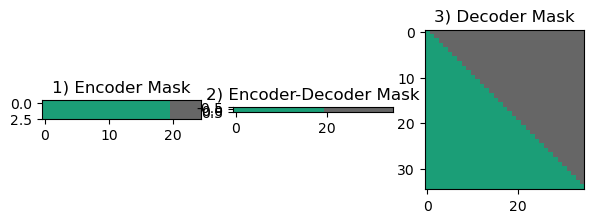

In [12]:
#아래 코드는 이전 설명 단계에 맞춰 그대로 실행하는 부분입니다.
import matplotlib.pyplot as plt

batch, length = 16, 20
src_padding = 5
tgt_padding = 15

src_pad = torch.zeros((batch, src_padding))
tgt_pad = torch.zeros((batch, tgt_padding))

sample_data = torch.ones((batch, length))
sample_src = torch.cat([sample_data, src_pad], dim=-1)
sample_tgt = torch.cat([sample_data, tgt_pad], dim=-1)

enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.set_title('1) Encoder Mask')
ax2.set_title('2) Encoder-Decoder Mask')
ax3.set_title('3) Decoder Mask')

ax1.imshow(enc_mask[:3, 0, 0].numpy(), cmap='Dark2')
ax2.imshow(dec_enc_mask[0, 0].numpy(), cmap='Dark2')
ax3.imshow(dec_mask[0, 0].numpy(), cmap='Dark2')

plt.show()

Decoder에서는 두 종류의 마스크가 필요했습니다.

- PAD를 가리는 마스크
- 아직 생성되지 않은 미래 단어를 보지 못하게 하는 마스크

또 Learning Rate도 고정값으로 두지 않고, 학습 단계에 따라 바뀌도록 설정했습니다. Transformer에서는 초반에 학습률을 서서히 올렸다가 이후 줄이는 방식이 자주 사용됩니다.


In [13]:
# 학습률이 단계에 따라 바뀌도록 설정합니다.
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = torch.tensor(step, dtype=torch.float32)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * torch.minimum(arg1, arg2)

model = nn.Linear(10, 10)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-9,
    betas=(0.9, 0.98),
    eps=1e-9)

print("슝=3")

슝=3


학습률 스케줄러는 학습이 진행되면서 Learning Rate를 자동으로 조절합니다.

Optimizer는 Adam을 사용했습니다. 이 부분은 모델이 실제로 loss를 줄이는 방향으로 파라미터를 업데이트하는 핵심 단계입니다.


# 번역기 개선 작업


## 수정하면서 확인한 문제들

기존 코드는 단순히 모델 크기만 부족한 문제가 아니었습니다. 마스크 처리, 학습 설정, 실행 환경 쪽에서도 문제가 있었습니다.

제가 수정하면서 확인한 핵심 문제는 다음과 같습니다.

1. Attention에서 마스크 방향이 반대로 적용되어 실제 단어가 가려졌습니다.
2. Cross-attention에 causal mask가 들어가 Decoder가 Encoder 전체를 제대로 보지 못했습니다.
3. SentencePiece 학습 인자에 오타가 있어 토크나이저 학습이 깨질 수 있었습니다.
4. Optimizer가 만들어지기 전에 Scheduler를 만드는 순서 문제가 있었습니다.
5. Embedding에 `sqrt(d_model)`을 곱하는 위치가 일관되지 않았습니다.
6. 경로 처리 방식이 Colab이 아닌 환경에서 깨질 수 있었습니다.

추가로 GPU 자동 사용, Pre-LN, GELU, Xavier 초기화, Label smoothing, 배치 단위 패딩, `<unk>` 회피 처리도 정리했습니다.

이번 수정에서 가장 중요했던 부분은 **마스크 의미를 코드 전체에서 하나로 통일하는 것**이었습니다.


## Step 1. 라이브러리와 디바이스 설정

필요한 라이브러리를 불러오고, GPU가 있으면 자동으로 GPU를 사용하도록 설정했습니다.


In [14]:
# 아래 코드는 이전 설명 단계에 맞춰 그대로 실행하는 부분입니다.
import os, re, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)


torch: 2.7.1+cu118 | device: cuda


## Step 2. 데이터 준비

번역 학습에 사용할 데이터를 준비했습니다. 로컬 환경과 Colab 환경을 모두 고려해서 경로가 깨지지 않도록 확인했습니다.


In [15]:
#아래 코드는 이전 설명 단계에 맞춰 그대로 실행하는 부분입니다.
HOME = os.getenv("HOME")
candidate_dirs = [
    os.path.join(HOME, "work/transformer/data"),
    "/content",
    ".",
]

DATA_DIR = None
for d in candidate_dirs:
    if os.path.exists(os.path.join(d, "korean-english-park.train.ko")):
        DATA_DIR = d
        break

if DATA_DIR is None:
    DATA_DIR = candidate_dirs[0]
    os.makedirs(DATA_DIR, exist_ok=True)
    url = ("https://github.com/jungyeul/korean-parallel-corpora/raw/"
           "master/korean-english-news-v1/korean-english-park.train.tar.gz")
    os.system(f"wget -q {url} -P {DATA_DIR}")
    os.system(f"gzip -df {DATA_DIR}/korean-english-park.train.tar.gz")
    os.system(f"tar -xf {DATA_DIR}/korean-english-park.train.tar -C {DATA_DIR}")

KOR_PATH = os.path.join(DATA_DIR, "korean-english-park.train.ko")
ENG_PATH = os.path.join(DATA_DIR, "korean-english-park.train.en")
print("DATA_DIR:", DATA_DIR)
print("kor:", os.path.exists(KOR_PATH), "eng:", os.path.exists(ENG_PATH))


DATA_DIR: /home/jovyan/work/transformer/data
kor: True eng: True


## Step 3. 문장 정제와 토큰화

문장을 바로 모델에 넣을 수는 없기 때문에 먼저 정리했습니다. 중복 문장을 제거하고, 문장부호와 특수문자를 정리한 뒤 SentencePiece로 토크나이저를 학습했습니다.


In [16]:
# 문장을 모델에 넣기 전에 기호와 공백을 정리합니다.
def preprocess_sentence(sentence: str) -> str:
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

def load_pairs(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)
    seen, pairs = set(), []
    for k, e in zip(kor, eng):
        key = k + "\t" + e
        if key in seen:
            continue
        seen.add(key)
        pairs.append((preprocess_sentence(k), preprocess_sentence(e)))
    return pairs

pairs = load_pairs(KOR_PATH, ENG_PATH)
print(f"중복 제거 후 병렬쌍: {len(pairs):,}")
print("예시:", pairs[0])

kor_corpus = [k for k, _ in pairs]
eng_corpus = [e for _, e in pairs]


중복 제거 후 병렬쌍: 78,968
예시: ('개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?', 'much of personal computing is about can you top this ?')


In [18]:
# 문장을 토큰 단위로 나누기 위해 SentencePiece 토크나이저를 학습합니다.
import sentencepiece as spm

SRC_VOCAB_SIZE = 8000
TGT_VOCAB_SIZE = 8000

def generate_tokenizer(corpus, vocab_size, lang,
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    txt_path = f"./{lang}_corpus.txt"
    model_prefix = f"./{lang}_spm"
    with open(txt_path, "w") as f:
        for row in corpus:
            f.write(row + "\n")

    # FIX: 원본 코드는 공백 누락 + '--pad_id==%d' (등호 두 개) 로 학습이 깨짐.
    spm.SentencePieceTrainer.Train(
        f"--input={txt_path} --model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} --character_coverage=0.9995 "
        f"--model_type=bpe "
        f"--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )
    tk = spm.SentencePieceProcessor()
    tk.Load(f"{model_prefix}.model")
    return tk

print("토크나이저 학습 중...")
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
print("ko vocab:", ko_tokenizer.get_piece_size(),
      "en vocab:", en_tokenizer.get_piece_size())
print("샘플 인코딩:", en_tokenizer.encode_as_pieces("hello world"))


토크나이저 학습 중...


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./ko_corpus.txt --model_prefix=./ko_spm --vocab_size=8000 --character_coverage=0.9995 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./ko_corpus.txt
  input_format: 
  model_prefix: ./ko_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_voca

ko vocab: 8000 en vocab: 8000
샘플 인코딩: ['<s>', '▁hel', 'lo', '▁world', '</s>']


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./en_corpus.txt --model_prefix=./en_spm --vocab_size=8000 --character_coverage=0.9995 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./en_corpus.txt
  input_format: 
  model_prefix: ./en_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_voca

## Step 4. 문장을 숫자로 바꾸기

토큰화된 문장을 숫자 ID로 바꿨습니다. 너무 긴 문장은 학습을 어렵게 만들 수 있어서 길이 40 이하의 문장만 사용했습니다.


In [19]:
#아래 코드는 이전 설명 단계에 맞춰 그대로 실행하는 부분입니다.
MAX_LEN = 40

src_corpus, tgt_corpus = [], []
for k, e in zip(kor_corpus, eng_corpus):
    s = ko_tokenizer.encode_as_ids(k)
    t = en_tokenizer.encode_as_ids(e)  # bos/eos 포함
    if 1 <= len(s) <= MAX_LEN and 3 <= len(t) <= MAX_LEN:
        src_corpus.append(torch.tensor(s, dtype=torch.long))
        tgt_corpus.append(torch.tensor(t, dtype=torch.long))

print(f"학습용 병렬쌍: {len(src_corpus):,}")
print("src 예시 len:", len(src_corpus[0]), "tgt 예시 len:", len(tgt_corpus[0]))


학습용 병렬쌍: 58,876
src 예시 len: 16 tgt 예시 len: 15


## Step 5. 모델 구성

이 단계에서는 Transformer 모델을 실제 학습에 사용할 수 있는 형태로 구성했습니다.

마스크는 `True == 가린다`는 기준으로 통일했습니다. 이 기준이 섞이면 Attention에서 실제 단어를 가리거나, 반대로 PAD를 보게 되는 문제가 생깁니다.


In [20]:
#문장 안에서 단어의 위치를 알려주는 positional encoding을 만듭니다.
def positional_encoding(pos_len, d_model):
    pe = np.zeros((pos_len, d_model), dtype=np.float32)
    position = np.arange(0, pos_len)[:, None]
    div_term = np.exp(np.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return torch.from_numpy(pe)  # [pos_len, d_model]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)

    def _split(self, x):
        b, t, _ = x.shape
        return x.view(b, t, self.num_heads, self.depth).transpose(1, 2)

    def _combine(self, x):
        b, h, t, d = x.shape
        return x.transpose(1, 2).contiguous().view(b, t, h * d)

    def forward(self, Q, K, V, mask=None):
        # mask: bool, True 인 위치를 가린다. shape broadcast-able to (B, H, Tq, Tk).
        Q = self._split(self.W_q(Q))
        K = self._split(self.W_k(K))
        V = self._split(self.W_v(V))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        out = torch.matmul(attn, V)
        out = self._combine(out)
        return self.linear(out), attn


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.gelu(self.w_1(x))))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        h = self.norm_1(x)
        h, attn = self.self_attn(h, h, h, src_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        x = x + self.dropout(self.ffn(h))
        return x, attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        h = self.norm_1(x)
        h, self_attn = self.self_attn(h, h, h, tgt_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        # FIX: cross-attention 에는 인코더 패딩 마스크만 (causal X)
        h, cross_attn = self.cross_attn(h, enc_out, enc_out, memory_mask)
        x = x + self.dropout(h)

        h = self.norm_3(x)
        x = x + self.dropout(self.ffn(h))
        return x, self_attn, cross_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, src_mask):
        attns = []
        for layer in self.layers:
            x, a = layer(x, src_mask)
            attns.append(a)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, tgt_mask, memory_mask)
            self_attns.append(sa); cross_attns.append(ca)
        return x, self_attns, cross_attns


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared=True):
        super().__init__()
        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.register_buffer("pos_encoding", positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size, bias=False)
        if shared:
            self.fc.weight = self.dec_emb.weight

        self._reset_parameters()

    def _reset_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _embed(self, emb, x):
        # FIX: shared 여부와 무관하게 항상 sqrt(d_model) 스케일
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[: x.size(1)].unsqueeze(0)
        return self.dropout(out)

    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask):
        enc_in = self._embed(self.enc_emb, src)
        dec_in = self._embed(self.dec_emb, tgt)

        enc_out, enc_attns = self.encoder(enc_in, src_mask)
        dec_out, dec_attns, cross_attns = self.decoder(
            dec_in, enc_out, tgt_mask, memory_mask
        )
        return self.fc(dec_out), enc_attns, dec_attns, cross_attns


print("모델 클래스 정의 완료")


모델 클래스 정의 완료


### 마스크 기준 정리

이 노트북에서는 마스크를 bool 텐서로 만들고, `True`인 위치를 가립니다.

- `src_mask`: Encoder에서 PAD 위치를 가립니다.
- `tgt_mask`: Decoder에서 PAD와 미래 위치를 가립니다.
- `memory_mask`: Decoder가 Encoder를 볼 때 Encoder의 PAD만 가립니다.

여기서 중요한 점은 Cross-attention에서는 미래 단어 마스크를 쓰지 않는다는 것입니다. 번역에서는 한국어와 영어의 단어 순서가 다를 수 있기 때문에, Decoder가 Encoder 출력 전체를 볼 수 있어야 합니다.


In [21]:
#PAD나 미래 단어처럼 보면 안 되는 위치를 마스크로 표시합니다.
def padding_mask(seq):
    # True 이면 PAD. shape: [B, 1, 1, T]
    return (seq == 0).unsqueeze(1).unsqueeze(2)

def causal_mask(size, device):
    # True 이면 미래 위치. shape: [1, 1, size, size]
    m = torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)
    return m.unsqueeze(0).unsqueeze(0)

def generate_masks(src, tgt):
    src_pad = padding_mask(src)                                # [B,1,1,Ts]
    tgt_pad = padding_mask(tgt)                                # [B,1,1,Tt]
    tgt_causal = causal_mask(tgt.size(1), tgt.device)          # [1,1,Tt,Tt]
    tgt_mask = tgt_pad | tgt_causal                            # broadcast → [B,1,Tt,Tt]
    memory_mask = src_pad                                      # cross-attn 은 enc padding 만
    return src_pad, tgt_mask, memory_mask


## Step 6. 하이퍼파라미터와 모델 생성

레이어 수, hidden size, head 수, batch size, epoch 같은 값을 정하고 모델을 생성했습니다.

이 값들은 모델 성능과 학습 속도에 직접 영향을 주기 때문에, 실험할 때 조절해야 하는 부분입니다.


In [22]:
#아래 코드는 이전 설명 단계에 맞춰 그대로 실행하는 부분입니다.
N_LAYERS = 4
D_MODEL  = 256
N_HEADS  = 8
D_FF     = 1024
DROPOUT  = 0.1
POS_LEN  = MAX_LEN + 2
BATCH_SIZE = 128
EPOCHS = 20
WARMUP_STEPS = 4000
LABEL_SMOOTH = 0.1

model = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE, tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN, dropout=DROPOUT, shared=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"파라미터 수: {n_params/1e6:.2f}M")


파라미터 수: 11.47M


## Step 7. Optimizer, Scheduler, Loss 설정

Adam Optimizer, Noam 방식의 학습률 스케줄, Label Smoothing Loss를 설정했습니다.

Label smoothing은 모델이 정답 하나에만 너무 과하게 확신하지 않도록 만드는 방법입니다. 번역처럼 답이 하나로만 고정되기 어려운 작업에서는 도움이 될 수 있다고 이해했습니다.


In [23]:
#학습률이 단계에 따라 바뀌도록 설정합니다.
def noam_lr(d_model, warmup):
    def lr(step):
        step = max(1, step)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
    return lr

optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam_lr(D_MODEL, WARMUP_STEPS))


class LabelSmoothingLoss(nn.Module):
    """Label smoothing + ignore PAD."""
    def __init__(self, vocab_size, pad_id=0, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.smoothing = smoothing

    def forward(self, logits, target):
        # logits: [B, T, V]; target: [B, T]
        logp = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.full_like(logp, self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(-1, target.unsqueeze(-1), 1.0 - self.smoothing)
            true_dist[:, :, self.pad_id] = 0
            mask = (target != self.pad_id).unsqueeze(-1)
            true_dist = true_dist * mask
        loss = -(true_dist * logp).sum(dim=-1)
        n_tok = (target != self.pad_id).sum().clamp(min=1)
        return loss.sum() / n_tok


criterion = LabelSmoothingLoss(TGT_VOCAB_SIZE, pad_id=PAD_ID, smoothing=LABEL_SMOOTH)
print("optimizer / scheduler / loss 준비 완료")


optimizer / scheduler / loss 준비 완료


## Step 8. 미니배치 패딩과 학습 루프

모든 문장을 처음부터 같은 길이로 맞추면 PAD가 너무 많이 생깁니다. 그래서 batch마다 필요한 만큼만 padding을 넣도록 했습니다.

이렇게 하면 메모리 낭비를 줄이고, 학습도 조금 더 효율적으로 진행할 수 있습니다.


In [25]:
# batch를 만들고 한 번 학습하는 과정을 함수로 정리합니다.
from torch.nn.utils.rnn import pad_sequence

train_idx = list(range(len(src_corpus)))

def make_batch(indices):
    src = pad_sequence([src_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    tgt = pad_sequence([tgt_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    return src.to(device), tgt.to(device)


def train_step(src, tgt):
    tgt_in  = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    src_mask, tgt_mask, memory_mask = generate_masks(src, tgt_in)
    # NOTE: src_mask, memory_mask 는 본질적으로 같은 인코더 패딩 마스크지만
    # encoder self-attn vs cross-attn 에 같이 쓰입니다.

    optimizer.zero_grad()
    logits, *_ = model(src, tgt_in, src_mask, tgt_mask, memory_mask)
    loss = criterion(logits, tgt_out)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    return loss.item()


In [27]:
# batch를 만들고 한 번 학습하는 과정을 함수로 정리합니다.
print(f"학습 시작: {EPOCHS} epochs, batch={BATCH_SIZE}, 데이터 {len(src_corpus):,} 문장")
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_idx)
    total, n = 0.0, 0
    for s in range(0, len(train_idx), BATCH_SIZE):
        batch = train_idx[s : s + BATCH_SIZE]
        if not batch:
            continue
        src, tgt = make_batch(batch)
        loss = train_step(src, tgt)
        total += loss; n += 1
    print(f"Epoch {epoch:2d} | avg loss {total/max(1,n):.4f} | "
          f"lr {scheduler.get_last_lr()[0]:.2e} | "
          f"elapsed {time.time()-t0:.1f}s")


학습 시작: 20 epochs, batch=128, 데이터 58,876 문장
Epoch  1 | avg loss 7.4406 | lr 1.14e-04 | elapsed 58.1s
Epoch  2 | avg loss 6.4932 | lr 2.27e-04 | elapsed 117.6s
Epoch  3 | avg loss 5.9177 | lr 3.41e-04 | elapsed 176.8s
Epoch  4 | avg loss 5.5581 | lr 4.55e-04 | elapsed 235.8s
Epoch  5 | avg loss 5.2538 | lr 5.68e-04 | elapsed 294.9s
Epoch  6 | avg loss 5.0109 | lr 6.82e-04 | elapsed 354.0s
Epoch  7 | avg loss 4.8241 | lr 7.96e-04 | elapsed 413.1s
Epoch  8 | avg loss 4.6736 | lr 9.09e-04 | elapsed 472.1s
Epoch  9 | avg loss 4.5519 | lr 9.71e-04 | elapsed 531.4s
Epoch 10 | avg loss 4.4071 | lr 9.22e-04 | elapsed 590.7s
Epoch 11 | avg loss 4.2629 | lr 8.79e-04 | elapsed 649.7s
Epoch 12 | avg loss 4.1370 | lr 8.41e-04 | elapsed 708.8s
Epoch 13 | avg loss 4.0276 | lr 8.08e-04 | elapsed 767.9s
Epoch 14 | avg loss 3.9332 | lr 7.79e-04 | elapsed 827.0s
Epoch 15 | avg loss 3.8503 | lr 7.52e-04 | elapsed 886.2s
Epoch 16 | avg loss 3.7768 | lr 7.29e-04 | elapsed 945.7s
Epoch 17 | avg loss 3.7111 | l

## Step 9. 번역 함수

학습된 모델로 실제 문장을 번역하는 함수입니다.

한 번에 전체 문장을 만드는 것이 아니라, 시작 토큰부터 출발해서 다음 단어를 하나씩 예측하며 문장을 만들어 갑니다.


In [28]:
# 문장을 모델에 넣기 전에 기호와 공백을 정리합니다.
@torch.no_grad()
def evaluate(sentence, max_len=MAX_LEN):
    model.eval()

    sent = preprocess_sentence(sentence)
    src_ids = ko_tokenizer.encode_as_ids(sent)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    generated = []
    enc_attns = dec_attns = cross_attns = None

    for _ in range(max_len):
        src_mask, tgt_mask, memory_mask = generate_masks(src, out)
        logits, enc_attns, dec_attns, cross_attns = model(
            src, out, src_mask, tgt_mask, memory_mask
        )
        next_logits = logits[0, -1].clone()
        next_logits[UNK_ID] = float("-inf")   # <unk> 회피
        next_id = int(torch.argmax(next_logits).item())

        if next_id == EOS_ID:
            break
        generated.append(next_id)
        out = torch.cat(
            [out, torch.tensor([[next_id]], device=device)], dim=-1
        )

    return en_tokenizer.decode_ids(generated), enc_attns, dec_attns, cross_attns


def translate(sentence):
    result, *_ = evaluate(sentence)
    return result


## Step 10. 번역 결과 확인

몇 가지 한국어 문장을 넣어서 번역 결과를 확인했습니다.

이 단계에서는 loss가 줄어드는 것만 보는 것이 아니라, 실제 출력 문장이 어느 정도 자연스러운지도 같이 확인해야 합니다.


In [29]:
# 예시 문장들을 넣어서 번역 결과를 확인합니다.
examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "그는 어제 학교에 갔다.",
    "한국은 아름다운 나라이다.",
    "정부는 새로운 정책을 발표했다.",
    "경제는 빠르게 성장하고 있다.",
    "그녀는 영어를 매우 잘한다.",
    "내일 비가 올 것 같다.",
]

print("=" * 70)
print(" Korean → English Translations")
print("=" * 70)
for i, s in enumerate(examples, 1):
    out = translate(s)
    print(f"{i:2d}. KO: {s}")
    print(f"    EN: {out}")
    print("-" * 70)

print()
print("Hyperparameters")
print(f"  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, "
      f"d_ff={D_FF}, dropout={DROPOUT}")
print(f"  vocab(src/tgt)={SRC_VOCAB_SIZE}/{TGT_VOCAB_SIZE}, "
      f"max_len={MAX_LEN}, warmup={WARMUP_STEPS}, "
      f"label_smooth={LABEL_SMOOTH}, batch={BATCH_SIZE}, epochs={EPOCHS}")


 Korean → English Translations
 1. KO: 오바마는 대통령이다.
    EN: obama is the president .
----------------------------------------------------------------------
 2. KO: 시민들은 도시 속에 산다.
    EN: the city is in the town of sir .
----------------------------------------------------------------------
 3. KO: 커피는 필요 없다.
    EN: it s not just coffee .
----------------------------------------------------------------------
 4. KO: 일곱 명의 사망자가 발생했다.
    EN: seven people were killed in the disaster .
----------------------------------------------------------------------
 5. KO: 그는 어제 학교에 갔다.
    EN: he was later sworn in the school .
----------------------------------------------------------------------
 6. KO: 한국은 아름다운 나라이다.
    EN: south korea is beautiful in the beautiful country .
----------------------------------------------------------------------
 7. KO: 정부는 새로운 정책을 발표했다.
    EN: the government has set a new policy to set a new government .
--------------------------------------------------------